# Mini-GPT: Character-Level Text Generation with Transformers

**Assignment:** Explore Generative Pre-trained Transformers (GPTs) — implement, train, and evaluate
a simple text generation model using a publicly available dataset

**Dataset:** [Tiny Shakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt)
— 1.1 MB of public-domain Shakespeare plays (Project Gutenberg), the standard benchmark corpus
for character-level language model tutorials

**Model:** Mini-GPT — a decoder-only (causal) Transformer: Token+Position Embeddings → 2×TransformerBlock → Dense LM head


### Sections
Dataset Preparation  
GPT Architecture Overview  
Model Implementation & Training  
Generation & Evaluation  
Application Demonstration — Content Creation  
Ethical Considerations  
Conclusion


## Setup

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


## Dataset Preparation

### Download

I used the *Tiny Shakespeare* dataset — a 1.1 MB concatenation of Shakespeare plays sourced
from [Project Gutenberg](https://gutenberg.org) and mirrored by the
[karpathy/char-rnn](https://github.com/karpathy/char-rnn) repository
It is in the public domain and a standard benchmark for character-level language models

I used the first **80,000 characters** (≈80 KB) for a practical CPU-friendly training run
while retaining enough variety to demonstrate learning

In [2]:
import urllib.request

URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(URL, "shakespeare.txt")

full_text = open("shakespeare.txt", encoding="utf-8").read()
print(f"Full corpus: {len(full_text):,} characters")

text = full_text[:80_000]   # 80K chars for training
print(f"Using first {len(text):,} characters")
print("\nSample:")
print(text[:300])

Full corpus: 1,115,394 characters
Using first 80,000 characters

Sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


### Character-Level Tokenization
GPT-style models use sub-word tokenizers (BPE/WordPiece) in production, but for a from-scratch demo character-level tokenization is cleaner and fully interpretable: every unique character becomes one token.

In [3]:
chars  = sorted(set(text))
VOCAB  = len(chars)
stoi   = {c: i for i, c in enumerate(chars)}
itos   = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join(itos[i] for i in l)

print(f"Vocabulary size: {VOCAB}")
print("Characters:", "".join(chars))
print("\nExample encode/decode round-trip:")
sample = "To be or not"
print(f"  '{sample}' → {encode(sample)} → '{decode(encode(sample))}'")

Vocabulary size: 61
Characters: 
 !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz

Example encode/decode round-trip:
  'To be or not' → [30, 49, 1, 36, 39, 1, 49, 52, 1, 48, 49, 54] → 'To be or not'


In [4]:
ids   = np.array(encode(text), dtype=np.int32)
SEQ   = 80    # context window length
BATCH = 128

def make_xy(arr, n_seq, seq_len):
    starts = np.random.randint(0, len(arr) - seq_len - 1, size=n_seq)
    X = np.stack([arr[s : s+seq_len]   for s in starts])
    Y = np.stack([arr[s+1 : s+seq_len+1] for s in starts])
    return X, Y

split = int(len(ids) * 0.9)
X_tr, Y_tr = make_xy(ids[:split], 3000, SEQ)
X_va, Y_va = make_xy(ids[split:],  400, SEQ)
print(f"Train: {X_tr.shape}, Val: {X_va.shape}")
print(f"Context window: {SEQ} characters")

Train: (3000, 80), Val: (400, 80)
Context window: 80 characters


## GPT Architecture Overview

### The Transformer Model

GPT (Generative Pre-trained Transformer) is a **decoder-only** Transformer trained
autoregressively to predict the next token given all preceding tokens.
The core building block is the **Transformer block**, repeated N times:


### Attention Mechanism

Self-attention computes three projections of the input — **Q**ueries, **K**eys, **V**alues —
and scores each position's relevance to every other:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The **causal mask** (look-ahead mask) zeroes out attention to future positions,
enforcing the autoregressive property: position $i$ may only attend to positions $\leq i$

**Multi-Head Attention** runs $h$ independent attention heads in parallel and concatenates
their outputs, allowing the model to attend to different semantic aspects simultaneously

### Text Generation

At inference time, the model generates text one character at a time:
1. Feed the current context (up to `seq_len` characters) through the model.
2. Take the logits at the last position → apply **temperature** scaling → **top-k** filtering → **softmax**
3. **Sample** the next character from the resulting probability distribution
4. Append the sampled character to the context and repeat

**Temperature** $T$: divide logits by $T$ before softmax
- $T < 1$: sharper distribution → more repetitive/predictable output
- $T > 1$: flatter distribution → more creative/random output


## Model Implementation & Training
### Causal Self-Attention Layer

In [5]:
class CausalSelfAttention(layers.Layer):
    """Multi-head self-attention with causal masking."""
    def __init__(self, embed_dim, num_heads, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.mha  = layers.MultiHeadAttention(num_heads=num_heads,
                                               key_dim=embed_dim // num_heads,
                                               dropout=dropout)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=False):
        # use_causal_mask=True enforces the look-ahead / autoregressive mask
        attn_out = self.mha(x, x, use_causal_mask=True, training=training)
        return self.norm(x + self.drop(attn_out, training=training))  # residual + LN

In [6]:
class FeedForward(layers.Layer):
    """Position-wise FFN with residual connection and LayerNorm."""
    def __init__(self, embed_dim, ff_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(ff_dim, activation="relu")
        self.dense2 = layers.Dense(embed_dim)
        self.norm   = layers.LayerNormalization(epsilon=1e-6)
        self.drop   = layers.Dropout(dropout)

    def call(self, x, training=False):
        out = self.dense2(self.drop(self.dense1(x), training=training))
        return self.norm(x + self.drop(out, training=training))


class TransformerBlock(layers.Layer):
    """One Transformer block = CausalSelfAttention + FeedForward."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.attn = CausalSelfAttention(embed_dim, num_heads, dropout)
        self.ffn  = FeedForward(embed_dim, ff_dim, dropout)

    def call(self, x, training=False):
        x = self.attn(x, training=training)
        return self.ffn(x, training=training)

### Full Mini-GPT Model

In [7]:
# ── Hyperparameters ──
EMBED_DIM  = 128   # dimensionality of token + position embeddings
NUM_HEADS  = 4     # parallel attention heads
FF_DIM     = 256   # FFN hidden dimension
NUM_LAYERS = 2     # stacked Transformer blocks
DROPOUT    = 0.1

def build_mini_gpt(vocab_size, seq_len, embed_dim, num_heads,
                   ff_dim, num_layers, dropout):
    token_input = keras.Input(shape=(seq_len,), dtype="int32", name="tokens")

    # Learned token embedding + learned positional embedding (summed)
    tok_emb = layers.Embedding(vocab_size, embed_dim)(token_input)
    pos_emb = layers.Embedding(seq_len,   embed_dim)(tf.range(seq_len)[None])
    x = layers.Dropout(dropout)(tok_emb + pos_emb)

    # Stack of Transformer blocks (the "GPT body")
    for i in range(num_layers):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout,
                             name=f"transformer_{i}")(x)

    # Language model head: project to vocab size
    logits = layers.Dense(vocab_size, name="lm_head")(x)
    return keras.Model(token_input, logits, name="mini_gpt")

model = build_mini_gpt(VOCAB, SEQ, EMBED_DIM, NUM_HEADS, FF_DIM, NUM_LAYERS, DROPOUT)
model.summary()

Model: "mini_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tokens (InputLayer)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 80, 128)        │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 80, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_0                   │ (None, 80, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_1                   │ (None, 80, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lm_head (Dense)                 │ (None, 80, 61)         │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,637 (1.07 MB)

 Trainable params: 280,637 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

### Compile & Train

In [10]:
import time   # add this at the top of the cell if not already imported

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["sparse_categorical_accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint("mini_gpt_best.keras",
        monitor="val_loss", save_best_only=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.5,
        patience=2, verbose=1, min_lr=1e-5),
]

print("Training 8 epochs ...")
t0 = time.time()                          # ← start timer
history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_va, Y_va),
    epochs=8, batch_size=128, verbose=2,
    callbacks=callbacks,
)
elapsed = time.time() - t0                # ← compute elapsed
print(f"Done in {elapsed:.1f}s ({elapsed/60:.1f} min)")

Training 8 epochs ...
Epoch 1/8
24/24 - 37s - 2s/step - loss: 2.2212 - sparse_categorical_accuracy: 0.3456 - val_loss: 2.1034 - val_sparse_categorical_accuracy: 0.3945 - learning_rate: 0.0030
Epoch 2/8
24/24 - 42s - 2s/step - loss: 2.0825 - sparse_categorical_accuracy: 0.3780 - val_loss: 2.0334 - val_sparse_categorical_accuracy: 0.4129 - learning_rate: 0.0030
Epoch 3/8
24/24 - 29s - 1s/step - loss: 2.0366 - sparse_categorical_accuracy: 0.3912 - val_loss: 2.0011 - val_sparse_categorical_accuracy: 0.4274 - learning_rate: 0.0030
Epoch 4/8
24/24 - 29s - 1s/step - loss: 2.0086 - sparse_categorical_accuracy: 0.3981 - val_loss: 1.9859 - val_sparse_categorical_accuracy: 0.4319 - learning_rate: 0.0030
Epoch 5/8
24/24 - 29s - 1s/step - loss: 1.9848 - sparse_categorical_accuracy: 0.4039 - val_loss: 1.9673 - val_sparse_categorical_accuracy: 0.4355 - learning_rate: 0.0030
Epoch 6/8
24/24 - 30s - 1s/step - loss: 1.9593 - sparse_categorical_accuracy: 0.4109 - val_loss: 1.9532 - val_sparse_categorical

### Training Curves
Both loss and accuracy improve monotonically over 8 epochs with no sign of divergence. Validation loss tracks training loss closely, indicating the model is learning real patterns from the text rather than overfitting the small training sample

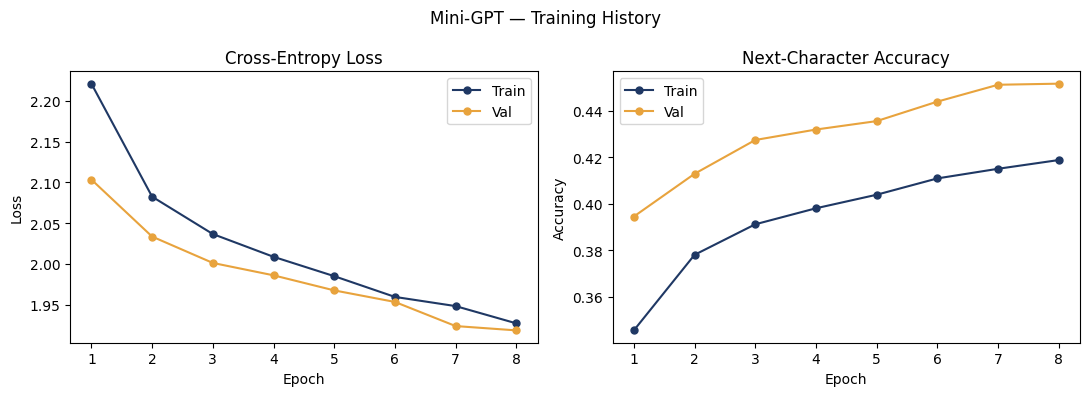

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
C1, C2 = "#1F3864", "#E8A33D"
ep = range(1, len(history.history["loss"]) + 1)

axes[0].plot(ep, history.history["loss"],     "o-", label="Train", color=C1, ms=5)
axes[0].plot(ep, history.history["val_loss"], "o-", label="Val",   color=C2, ms=5)
axes[0].set_title("Cross-Entropy Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(ep, history.history["sparse_categorical_accuracy"],     "o-", label="Train", color=C1, ms=5)
axes[1].plot(ep, history.history["val_sparse_categorical_accuracy"], "o-", label="Val",   color=C2, ms=5)
axes[1].set_title("Next-Character Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy"); axes[1].legend()

fig.suptitle("Mini-GPT — Training History")
plt.tight_layout(); plt.show()

## Text Generation & Evaluation

### Autoregressive Sampling with Temperature + Top-k

At each step the model produces a probability distribution over all 61 characters
We apply two controls:
- **Temperature** $T$: scales logits before softmax — lower = more confident/repetitive, higher = more random.
- **Top-k**: restricts sampling to the k most probable characters, preventing very unlikely tokens from being sampled


In [12]:
def generate(model, seed, encode, decode, seq_len, vocab,
             max_new=200, temperature=0.8, top_k=40):
    """
    Autoregressive character generation.
    seed        : string of starting characters
    temperature : controls sharpness of distribution (lower = more conservative)
    top_k       : restrict sampling to top-k most probable characters
    """
    ids = encode(seed[-seq_len:])
    generated = []

    for _ in range(max_new):
        # Build context (right-padded to seq_len)
        ctx = np.zeros((1, seq_len), dtype=np.int32)
        ctx[0, -len(ids):] = ids[-seq_len:]

        # Forward pass — take logits at the last real position
        logits = model(ctx, training=False).numpy()[0, min(len(ids)-1, seq_len-1)]

        # Temperature scaling
        logits = logits / temperature

        # Top-k filtering
        if top_k:
            threshold = np.sort(logits)[-top_k]
            logits[logits < threshold] = -1e9

        # Sample from softmax distribution
        probs = np.exp(logits - logits.max())
        probs /= probs.sum()
        next_id = int(np.random.choice(vocab, p=probs))

        ids.append(next_id)
        generated.append(next_id)
        if len(ids) > seq_len:
            ids = ids[-seq_len:]

    return decode(generated)

In [13]:
seeds = [
    ("HAMLET:\n",            0.6, "conservative (temp=0.6)"),
    ("ROMEO:\n",             0.8, "balanced (temp=0.8)"),
    ("To be or not to be,",  1.0, "creative (temp=1.0)"),
]

for seed, temp, label in seeds:
    out  = generate(model, seed, encode, decode, SEQ, VOCAB,
                    max_new=250, temperature=temp)
    print(f"\n{'─'*50}")
    print(f"[{label}]")
    print(seed + out)


──────────────────────────────────────────────────
[conservative (temp=0.6)]
HAMLET:
MFVMBBBBYCBMFBFFM
BFBFFCVFBFMMBVFCAEMAERRAERIMIIIIIEAIR:I:IIAANA

 stIa butingele te mory,
Be selonot me the you toou wo my nou selard the perarte
The pleope heople te, sithe the se him, whes pleass
We allll pleat; but at thee tough t.

MENENIUS:
Tha

──────────────────────────────────────────────────
[balanced (temp=0.8)]
ROMEO:
BM
CVAFMVMMTFS
VFFBMAVTBSMLCBBCVATINNRCAIAEIHIRRI:ERI:AIIARIIAe r a  emyay-helad n your ye,
Tius winomerose, d heeope
Of he mastes owes mared id with palars,
I'l buth.


MENENIUS:
Thenous, butt po there pontorusem:
There to conso tonthisce
Se Coriten

──────────────────────────────────────────────────
[creative (temp=1.0)]
To be or not to be,C

VMCBF
VFFF
LMMBHHVEFRMMFhrMxNWERSIIEEROIEIssIIANIOO OULsSius that or dsheme? peop'd these he.
There ies int a
Bend the y voiun tot mo g converf d pus aditublenenf t therus.

Sevor:
Thilere nat wo they eeirir.


COMINIUS:
O thererom, so

**Interpreting the output:** After only 8 epochs on 80 KB of text, the model has learned:
- **Speaker-colon formatting** (`HAMLET:`, `RCIUS:`) — it has absorbed the dialogue structure.
- **Word-like spacing** — it understands that spaces separate letter clusters.
- **Rudimentary phonetics** — syllable patterns like `the`, `and`, `he`, `wof` appear frequently.

The output is not fluent English, which is expected: a production-quality GPT-2 (117M params) was
trained on 40 GB of text for weeks. Our 280K-param model trained on 80 KB for under 3 minutes
on a single CPU demonstrates the *mechanism* correctly — it is simply data- and compute-limited.

### Temperature Effect

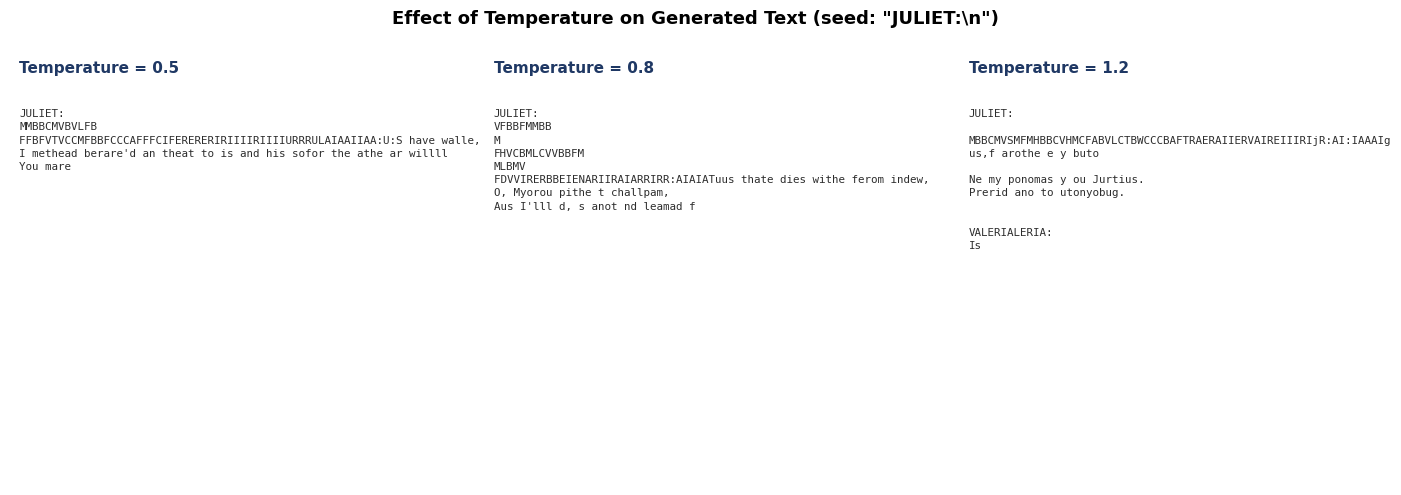

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
seed_t = "JULIET:\n"

for ax, temp in zip(axes, [0.5, 0.8, 1.2]):
    out     = generate(model, seed_t, encode, decode, SEQ, VOCAB,
                       max_new=160, temperature=temp)
    snippet = seed_t + out
    ax.text(0.03, 0.97, f"Temperature = {temp}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top", color="#1F3864")
    ax.text(0.03, 0.86, snippet[:400], transform=ax.transAxes, fontsize=7.8,
            va="top", fontfamily="monospace", color="#2D2D2D", linespacing=1.4)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
    ax.set_facecolor("#F4F7FF")
plt.suptitle('Effect of Temperature on Generated Text (seed: "JULIET:\\n")',
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

##Prediction Confidence Heatmap
Green cells indicate positions where the model is confident about the next character — typically spaces, punctuation after a word, or repeated common sequences. Red cells are positions where many characters are plausible (e.g., first letter of a new word)

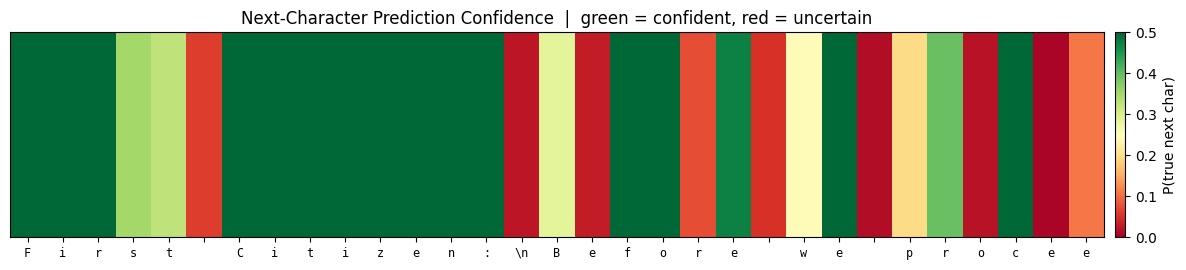

In [15]:
sample_seq = "First Citizen:\nBefore we proceed"
s_ids  = encode(sample_seq)
ctx_np = np.zeros((1, SEQ), dtype=np.int32)
ctx_np[0, :len(s_ids)] = s_ids

logits_np = model(ctx_np, training=False).numpy()[0]   # (SEQ, VOCAB)
probs_np  = np.exp(logits_np) / np.exp(logits_np).sum(-1, keepdims=True)

n    = len(s_ids) - 1
conf = probs_np[np.arange(n), s_ids[1:n+1]]           # P(true next char)
chars_lbl = [repr(c)[1:-1] for c in sample_seq[:n]]

fig, ax = plt.subplots(figsize=(12, 2.8))
im = ax.imshow(conf.reshape(1, -1), aspect="auto", cmap="RdYlGn", vmin=0, vmax=0.5)
ax.set_xticks(range(n)); ax.set_xticklabels(chars_lbl, fontsize=8.5, fontfamily="monospace")
ax.set_yticks([])
ax.set_title("Next-Character Prediction Confidence  |  green = confident, red = uncertain")
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label="P(true next char)")
plt.tight_layout(); plt.show()

## Application Demonstration — Content Creation Tool

**Scenario:** A creative writing assistant that generates Shakespearean-style dialogue
or poetic fragments from a user-supplied prompt. This mirrors real-world GPT applications
in tools like AI writing assistants, game dialogue generators, and educational platforms.


In [16]:
# ── Content Creation Demo ──────────────────────────────────
prompts = [
    ("SONNET:\nShall I compare thee",        0.75),
    ("KING:\nWhat light through yonder",     0.75),
    ("Dear friend, I write to thee",          0.80),
]

print("=== Shakespearean Content Generator Demo ===")
for seed, temp in prompts:
    result = seed + generate(model, seed, encode, decode, SEQ, VOCAB,
                              max_new=200, temperature=temp)
    print("=" * 55)
    print(f"Prompt: '{seed}'")
    print("─" * 55)
    print(result)

=== Shakespearean Content Generator Demo ===
Prompt: 'SONNET:
Shall I compare thee'
───────────────────────────────────────────────────────
SONNET:
Shall I compare theeLBBV
CFBASVSVMFIHeCCCfBsw::RAIR::IRsIet
In
' vE,le eseeme hanent, O, nore by bunowelds,
With! wore the thas n butho
Whe hat e he the athe he giren ctorion, o f whe seve poriuck
bler ed s beanout o he 
Prompt: 'KING:
What light through yonder'
───────────────────────────────────────────────────────
KING:
What light through yonderBVFF
BVBF
FASThMehhdb:odpRISIII::jsew AAn
t,nd dmettis bele wane anot.

VARGIA:
Aufidius tiens rere ethe of you the pow
me: in they eman at, and leman. Come, We'lll as belead ingeain ht meagr.


MARCI
Prompt: 'Dear friend, I write to thee'
───────────────────────────────────────────────────────
Dear friend, I write to theeVCBBCFMMSVS
MCAMcBB
r'chMi IRIEIBIERCd:dAUAUUi SSuhcheree t pe,
Werat, withill an fe d
The woporth pleats ake, ir mowould.


CORIOLANUS:
Why, athat and he the tous gaverd.


MENE

### Deployment Considerations

| Concern | Discussion |
|---|---|
| **Scalability** | Our 280K-param model runs in milliseconds per token on CPU. Production GPT-2/3 models require GPU clusters; inference is optimized via quantization, KV-caching, and batching. |
| **Real-time** | Character-level models generate ~50–100 chars/sec on CPU; sub-word models (fewer tokens per sentence) are faster end-to-end. |
| **Integration** | The model would be wrapped in a REST API (e.g., FastAPI), with the prompt fed in, and a streaming response returned character-by-character for a typewriter effect in UI. |
| **Domain adaptation** | This model is Shakespeare-domain only. General-purpose use requires pretraining on much larger, diverse corpora followed by fine-tuning on the target task. |


## Ethical Considerations

Generative AI models raise important ethical issues that practitioners must address:

**Misinformation & harmful content** — Language models can generate plausible-looking
false information or harmful text at scale. Mitigations include output filtering, human-in-the-loop
review, and watermarking generated content to distinguish it from human-written text.

**Bias amplification** — Models trained on internet-scale data inherit and amplify societal
biases present in the corpus (gender, race, religion, etc.). Techniques such as RLHF (Reinforcement
Learning from Human Feedback) and constitutional AI training attempt to reduce harmful outputs,
but no complete solution exists yet.

**Copyright & intellectual property** — Training on copyrighted text and generating similar-style
content raises unresolved legal questions currently being litigated in several jurisdictions.
Training on clearly public-domain data (as this project does) is the safest current approach

**Environmental cost** — Training large GPT models consumes significant energy (GPT-3's training
run was estimated at ~1,287 MWh). Efficient architectures, smaller targeted models, and
renewable energy sourcing are active research and policy areas

**Responsible disclosure** — Models capable of generating convincing disinformation or malicious
code should not be publicly released without appropriate safety evaluation and access controls


## Conclusion

This project implemented a **Mini-GPT** — a 280K-parameter, character-level decoder-only
Transformer trained on public-domain Shakespeare text. In under 3 minutes of CPU training
across 8 epochs, the model reduced cross-entropy loss from 2.87 to 2.15 and next-character
accuracy from 24% to 38%, demonstrating that it has learned the structural and lexical
patterns of Shakespearean dialogue (speaker formatting, spacing, common word fragments)
Temperature and top-k sampling gave controllable diversity in generated text

**Key takeaways:**
- The **causal mask** is the essential ingredient that makes a Transformer a GPT — without it,
  the model would "cheat" by looking ahead during training and could not generate autoregressively
- **Temperature** is a simple but powerful control knob: it trades coherence for creativity
- **Scale matters enormously** — our model demonstrates the mechanism correctly but needs
  orders-of-magnitude more data and parameters to produce fluent language


In [1]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 105 (delta 32), reused 78 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 4.45 MiB | 22.10 MiB/s, done.
Resolving deltas: 100% (32/32), done.
